# Multi-Aspect Sentiment Analysis of Indonesian Hotel Reviews Using Hybrid Classifier Based on SVM, NB, RF, and K-NN.

## Dataset
1. dataset yang digunakan dari indoNLU. 
2. URL: https://github.com/IndoNLP/indonlu/blob/master/dataset/hoasa_absa-airy/train_preprocess.csv 

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
nltk.download('stopwords')
nltk.download('punkt')
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
# Stopword dan stemmer
stop_factory = StopWordRemoverFactory()
stopwords = stop_factory.get_stop_words()
stemmer = StemmerFactory().create_stemmer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Load Dataset

In [2]:
# Load data training dan testing
train_df = pd.read_csv('train_preprocess.csv')
test_df = pd.read_csv('test_preprocess.csv')

# Tampilkan 5 baris pertama untuk memastikan
print(train_df.head())
print(test_df.head())

                                              review    ac air_panas   bau  \
0                               kebersihan kurang...  neut      neut  neut   
1  sangat mengecewakan... hotel bad image, kebers...  neut      neut  neut   
2  Tempat nyaman bersih tapi tv terlalu tinggi ti...  neut      neut  neut   
3  semuanya bagus sesuai profile,dan harga promo ...  neut       neg  neut   
4  Tempat tidur sangat keras, bantal besar dan ke...   neg       neg  neut   

  general kebersihan linen service sunrise_meal    tv  wifi  
0    neut        neg  neut    neut         neut  neut  neut  
1    neut        neg  neut    neut         neut  neut  neut  
2    neut        pos  neut    neut         neut   neg  neut  
3     pos       neut  neut    neut         neut  neut  neut  
4    neut       neut   neg    neut         neut  neut  neut  
                                              review    ac air_panas   bau  \
0  lumayan nyaman,tp kebersihan kmr mandi perlu d...  neut      neut  neut   
1  

In [3]:
# Mapping label ke angka
label_mapping = {
    "neg": 0,
    "neut": 1,
    "pos": 2,
    "neg_pos": 3
}

# Daftar aspek
aspek_sentimen = [
    "ac",
    "air_panas",
    "bau",
    "general",
    "kebersihan",
    "linen",
    "service",
    "sunrise_meal",
    "tv",
    "wifi"
]

# Proses mapping untuk dataset training
for col in aspek_sentimen:
    train_df[col] = train_df[col].str.lower().map(label_mapping)

# Proses mapping untuk dataset testing
for col in aspek_sentimen:
    test_df[col] = test_df[col].str.lower().map(label_mapping)

# Cek hasil
print("Training set:")
print(train_df[aspek_sentimen].head())

print("\nTesting set:")
print(test_df[aspek_sentimen].head())

Training set:
   ac  air_panas  bau  general  kebersihan  linen  service  sunrise_meal  tv  \
0   1          1    1        1           0      1        1             1   1   
1   1          1    1        1           0      1        1             1   1   
2   1          1    1        1           2      1        1             1   0   
3   1          0    1        2           1      1        1             1   1   
4   0          0    1        1           1      0        1             1   1   

   wifi  
0     1  
1     1  
2     1  
3     1  
4     1  

Testing set:
   ac  air_panas  bau  general  kebersihan  linen  service  sunrise_meal  tv  \
0   1          1    1        1           0      1        1             1   1   
1   1          1    1        1           0      0        1             1   1   
2   1          1    0        2           1      1        1             1   1   
3   1          1    1        1           1      1        1             1   1   
4   1          1    1        2 

### Exploratory Data Analysis (EDA)

In [4]:
# Cek jumlah NaN per kolom pada train_df
print("Missing values per kolom (train_df):\n", train_df[aspek_sentimen].isnull().sum())

# Hapus baris dengan NaN pada label aspek di train_df
train_df = train_df.dropna(subset=aspek_sentimen)
print(f"\nJumlah baris setelah drop NaN pada train_df: {len(train_df)}")

# Cek jumlah NaN per kolom pada test_df
print("\nMissing values per kolom (test_df):\n", test_df[aspek_sentimen].isnull().sum())

# Hapus baris dengan NaN pada label aspek di test_df
test_df = test_df.dropna(subset=aspek_sentimen)
print(f"\nJumlah baris setelah drop NaN pada test_df: {len(test_df)}")

Missing values per kolom (train_df):
 ac              0
air_panas       0
bau             0
general         0
kebersihan      0
linen           0
service         0
sunrise_meal    0
tv              0
wifi            0
dtype: int64

Jumlah baris setelah drop NaN pada train_df: 2283

Missing values per kolom (test_df):
 ac              0
air_panas       0
bau             0
general         0
kebersihan      0
linen           0
service         0
sunrise_meal    0
tv              0
wifi            0
dtype: int64

Jumlah baris setelah drop NaN pada test_df: 286


#### Noise Detection

In [5]:
# Deteksi noise words (kata yang mengandung angka) di train_df
train_words = train_df['review'].str.split().explode()
train_noise = train_words[train_words.str.contains(r'\d', na=False)]

print("Kata-kata mengandung angka di train_df (diduga noise):")
print(train_noise.unique())

print("\n" + "="*60 + "\n")

# Deteksi noise words di test_df
test_words = test_df['review'].str.split().explode()
test_noise = test_words[test_words.str.contains(r'\d', na=False)]

print("Kata-kata mengandung angka di test_df (diduga noise):")
print(test_noise.unique())

Kata-kata mengandung angka di train_df (diduga noise):
['1' '7' 'hewan2' 'mati2' '5' '306.' '1.' '2.' '2' 'mana2.' 'bolong2' '6'
 '1,5' 'laba2..kmr' 'ganti2.' 'tiba2' 'remang2..' '6pcs.' '24' '4,' '30'
 '195' '3.' '4.' '5.' '6.' 'kmn2.' '13:15,' '2,' '50rb' '50rb.' '3,' '2x'
 'gara2' '15menit' '202' '100rban' '7.' '1,' '1-2' '4' 'kemana2.' '1org'
 'dtg2,ga' '3' 'apa2' '64,..Baru' 'ramah2' 'ganteng2' 'anak2' 'lt.3.'
 'ngos2an.' 'mana2' 'tmn2' 'gitu2an,' '18.' 'seneng2' '100rb.'
 'langit2nya.' 'rata2' '14' '17' '11' 'marah2' 'nunjuk2' '22.10)' '23.00'
 'kemana2' '5-10rb' '305' 'dimana2.' 'santai2' 'jutek2' '25°C' 'hitam2'
 '5rb' '219' '12' '209' 'sisi2' 'psan2' 'sinyal4G' 'Tipe2' '7,' '21'
 'sudut2' 'laba2' 'bagus2' '05:00' '23:00' '7.30' '221' '2mlm,' '16'
 'bintik2' '2jam' 'teman2' '8,5/10' '2kmr' 'bercak2' 'ilang2an,' 'denda2,'
 'rambut2' 'noda2..' 'hotel2' '10' 'berlama2' 'jam15.30.' '1..tp' 'jujur2'
 'buat2,tq' '8' 'pagi2' 'sangat2' '100' 'bo2' 'kamar2' '50k' 'buru2'
 'teriak2' '1-1

#### Check Distribution for each Aspects

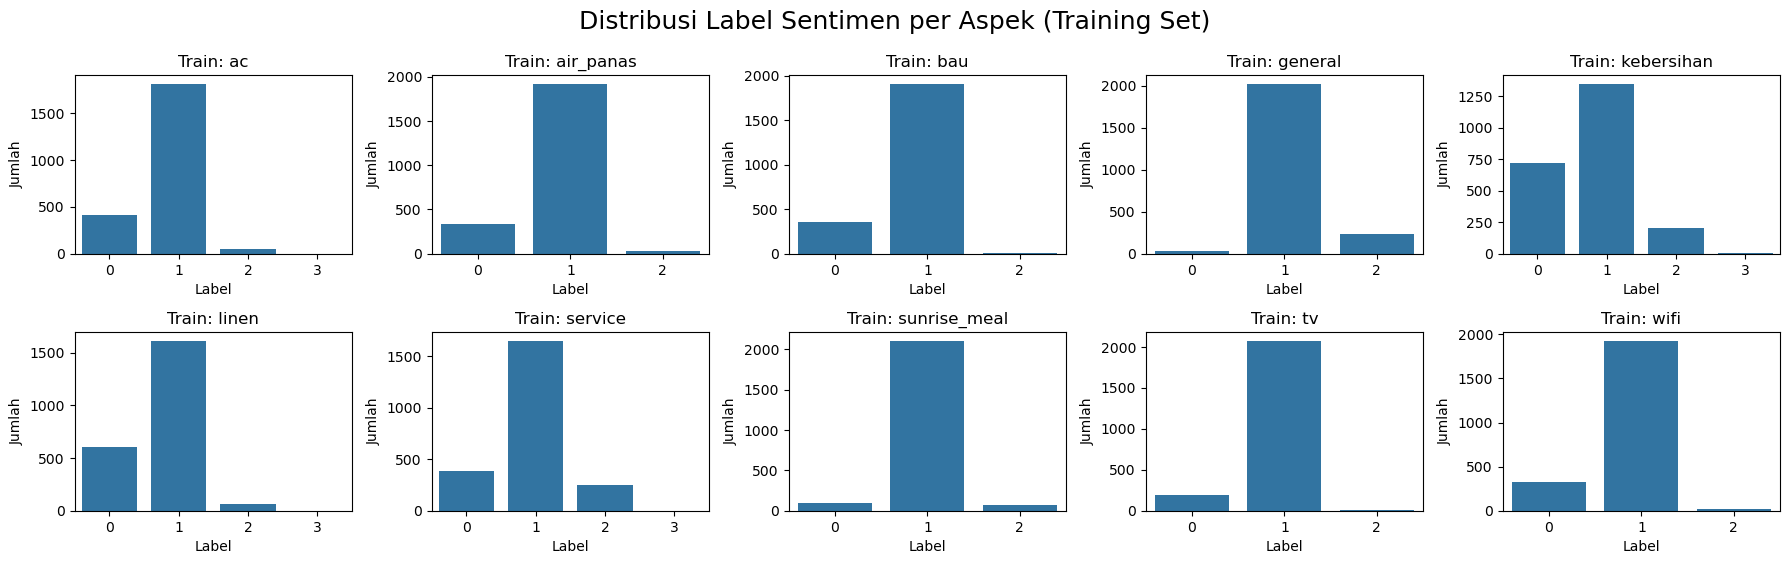

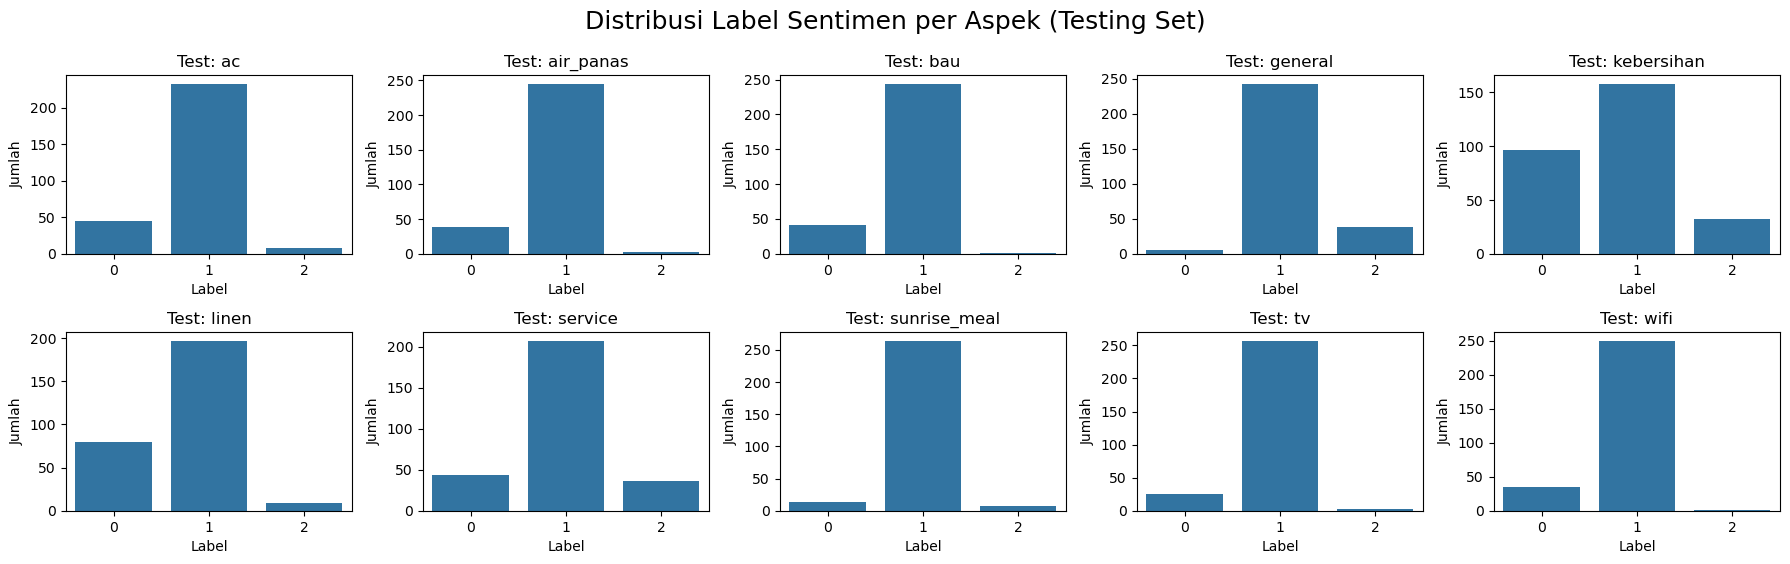

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# === Visualisasi train_df ===
plt.figure(figsize=(18, 10))
for i, aspek in enumerate(aspek_sentimen, 1):
    plt.subplot(4, 5, i)
    sns.countplot(x=aspek, data=train_df)
    plt.title(f"Train: {aspek}")
    plt.xlabel("Label")
    plt.ylabel("Jumlah")
plt.tight_layout()
plt.suptitle("Distribusi Label Sentimen per Aspek (Training Set)", fontsize=18, y=1.03)
plt.show()

# === Visualisasi test_df ===
plt.figure(figsize=(18, 10))
for i, aspek in enumerate(aspek_sentimen, 1):
    plt.subplot(4, 5, i)
    sns.countplot(x=aspek, data=test_df)
    plt.title(f"Test: {aspek}")
    plt.xlabel("Label")
    plt.ylabel("Jumlah")
plt.tight_layout()
plt.suptitle("Distribusi Label Sentimen per Aspek (Testing Set)", fontsize=18, y=1.03)
plt.show()

### Preprocessing Data

#### Symbol puntuation removal

In [7]:
def remove_symbols_and_numbers(text):
    """
    Menghapus semua karakter kecuali huruf dan spasi.
    Fungsi ini secara efektif membersihkan:
    - Tanda baca (.,!?:;()[]{}#)
    - Angka (0-9)
    - Simbol lainnya (@$%^&*)
    """
    # Langkah 1: Ganti semua karakter yang BUKAN huruf dengan spasi.
    # Ini mencegah kata-kata seperti "profile,dan" menjadi "profiledan".
    cleaned_text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    # Langkah 2: Menghapus spasi berlebih yang mungkin muncul setelah penggantian.
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    
    return cleaned_text

# ---- PENERAPAN PADA DATASET ANDA ----

# 1. Muat data training dan testing Anda
# Pastikan file 'train_preprocess.csv' dan 'test_preprocess.csv' ada di direktori yang sama
try:
    # 2. Terapkan fungsi ke kolom 'review' pada kedua DataFrame
    train_df['symbol_puntuation_removal'] = train_df['review'].apply(remove_symbols_and_numbers)
    test_df['symbol_puntuation_removal'] = test_df['review'].apply(remove_symbols_and_numbers)

    # 3. Lihat hasil untuk train_df
    print("Hasil untuk train_df setelah Symbol/Punctuation Removal (diperbaiki):")
    print(train_df[['review', 'symbol_puntuation_removal']].head())

    print("\n" + "="*60 + "\n")

    # 4. Lihat hasil untuk test_df
    print("Hasil untuk test_df setelah Symbol/Punctuation Removal (diperbaiki):")
    print(test_df[['review', 'symbol_puntuation_removal']].head())

except FileNotFoundError:
    print("Pastikan file 'train_preprocess.csv' dan 'test_preprocess.csv' berada di direktori yang benar.")

Hasil untuk train_df setelah Symbol/Punctuation Removal (diperbaiki):
                                              review  \
0                               kebersihan kurang...   
1  sangat mengecewakan... hotel bad image, kebers...   
2  Tempat nyaman bersih tapi tv terlalu tinggi ti...   
3  semuanya bagus sesuai profile,dan harga promo ...   
4  Tempat tidur sangat keras, bantal besar dan ke...   

                           symbol_puntuation_removal  
0                                  kebersihan kurang  
1  sangat mengecewakan hotel bad image kebersihan...  
2  Tempat nyaman bersih tapi tv terlalu tinggi ti...  
3  semuanya bagus sesuai profile dan harga promo ...  
4  Tempat tidur sangat keras bantal besar dan ker...  


Hasil untuk test_df setelah Symbol/Punctuation Removal (diperbaiki):
                                              review  \
0  lumayan nyaman,tp kebersihan kmr mandi perlu d...   
1  kamarnya kurang maintenance. paling baik kamar...   
2  harga terjangkau, kam

#### Case Folding

In [8]:
# --- TAHAP 2: CASE FOLDING ---
# Tahap ini dijalankan setelah cell sebelumnya (symbol/punctuation removal) dieksekusi.
# Kita asumsikan train_df dan test_df sudah memiliki kolom 'symbol_puntuation_removal'.

print("Menerapkan Case Folding...")

# Mengubah semua teks di kolom 'symbol_puntuation_removal' menjadi huruf kecil
train_df['case_folding'] = train_df['symbol_puntuation_removal'].str.lower()
test_df['case_folding'] = test_df['symbol_puntuation_removal'].str.lower()

# Menampilkan hasil untuk train_df
print("Hasil untuk train_df setelah Case Folding:")
print(train_df[['symbol_puntuation_removal', 'case_folding']].head())

print("\n" + "="*60 + "\n")

# Menampilkan hasil untuk test_df
print("Hasil untuk test_df setelah Case Folding:")
print(test_df[['symbol_puntuation_removal', 'case_folding']].head())

Menerapkan Case Folding...
Hasil untuk train_df setelah Case Folding:
                           symbol_puntuation_removal  \
0                                  kebersihan kurang   
1  sangat mengecewakan hotel bad image kebersihan...   
2  Tempat nyaman bersih tapi tv terlalu tinggi ti...   
3  semuanya bagus sesuai profile dan harga promo ...   
4  Tempat tidur sangat keras bantal besar dan ker...   

                                        case_folding  
0                                  kebersihan kurang  
1  sangat mengecewakan hotel bad image kebersihan...  
2  tempat nyaman bersih tapi tv terlalu tinggi ti...  
3  semuanya bagus sesuai profile dan harga promo ...  
4  tempat tidur sangat keras bantal besar dan ker...  


Hasil untuk test_df setelah Case Folding:
                           symbol_puntuation_removal  \
0  lumayan nyaman tp kebersihan kmr mandi perlu d...   
1  kamarnya kurang maintenance paling baik kamar ...   
2  harga terjangkau kamar luas ada sofa semua oke..

#### Tokenized

In [9]:
# --- TAHAP 3: TOKENIZATION ---
# Tahap ini dijalankan setelah cell sebelumnya (case folding) dieksekusi.
# Kita asumsikan train_df dan test_df sudah memiliki kolom 'case_folding'.

# Coba unduh 'punkt' dari NLTK, yang diperlukan untuk tokenisasi.
# Jika sudah ada, proses akan dilewati.
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    print("Mengunduh package 'punkt' untuk NLTK...")
    nltk.download('punkt')
    print("Unduhan selesai.")

print("\nMenerapkan Tokenization...")

# Menerapkan fungsi word_tokenize pada kolom 'case_folding'
train_df['tokenized'] = train_df['case_folding'].apply(word_tokenize)
test_df['tokenized'] = test_df['case_folding'].apply(word_tokenize)

# Menampilkan hasil untuk train_df
print("Hasil untuk train_df setelah Tokenization:")
print(train_df[['case_folding', 'tokenized']].head())

print("\n" + "="*60 + "\n")

# Menampilkan hasil untuk test_df
print("Hasil untuk test_df setelah Tokenization:")
print(test_df[['case_folding', 'tokenized']].head())


Menerapkan Tokenization...
Hasil untuk train_df setelah Tokenization:
                                        case_folding  \
0                                  kebersihan kurang   
1  sangat mengecewakan hotel bad image kebersihan...   
2  tempat nyaman bersih tapi tv terlalu tinggi ti...   
3  semuanya bagus sesuai profile dan harga promo ...   
4  tempat tidur sangat keras bantal besar dan ker...   

                                           tokenized  
0                               [kebersihan, kurang]  
1  [sangat, mengecewakan, hotel, bad, image, kebe...  
2  [tempat, nyaman, bersih, tapi, tv, terlalu, ti...  
3  [semuanya, bagus, sesuai, profile, dan, harga,...  
4  [tempat, tidur, sangat, keras, bantal, besar, ...  


Hasil untuk test_df setelah Tokenization:
                                        case_folding  \
0  lumayan nyaman tp kebersihan kmr mandi perlu d...   
1  kamarnya kurang maintenance paling baik kamar ...   
2  harga terjangkau kamar luas ada sofa semua oke.

#### Normalization

In [10]:
# --- TAHAP 4: NORMALIZATION ---
# Tahap ini dijalankan setelah cell sebelumnya (tokenization) dieksekusi.
# Kita asumsikan train_df dan test_df sudah memiliki kolom 'tokenized'.

# Kamus untuk normalisasi kata-kata tidak baku, singkatan, dan kata ulang
# Kamus ini dibuat berdasarkan temuan noise pada tahap EDA.
normalization_dict = {
    'sangat2': 'sangat', 'bener2': 'benar', 'benar2': 'benar', 'beneer2': 'benar',
    'banget2': 'banget', 'sekali2': 'sekali', 'ramah2': 'ramah', 'baik2': 'baik',
    'bagus2': 'bagus', 'enak2': 'enak', 'bersih2': 'bersih', 'ganteng2': 'ganteng',
    'jutek2': 'jutek', 'marah2': 'marah', 'gatal2': 'gatal', 'gatel2': 'gatal',
    'kotor2': 'kotor', 'rusak2': 'rusak', 'bolong2': 'bolong', 'hitam2': 'hitam',
    'bintik2': 'bintik', 'bercak2': 'bercak', 'putus2': 'putus', 'miring2': 'miring',
    
    'laba2': 'laba-laba', 'alun2': 'alun-alun', 'apa2': 'apa-apa', 'siap2': 'siap-siap',
    'hati2': 'hati-hati', 'mana2': 'mana-mana', 'kemana2': 'kemana-mana', 'dimana2': 'di mana-mana',
    'gara2': 'gara-gara', 'sama2': 'sama-sama', 'tiba2': 'tiba-tiba', 'pagi2': 'pagi-pagi',
    'buru2': 'buru-buru', 'kadang2': 'kadang-kadang', 'lain2': 'lain-lain',
    
    'anak2': 'anak-anak', 'kamar2': 'kamar-kamar', 'teman2': 'teman-teman', 'tmn2': 'teman-teman',
    'karyawan2': 'karyawan-karyawan', 'barang2': 'barang-barang', 'hotel2': 'hotel-hotel',
    
    'kmn2': 'kemana-mana', 't4': 'tempat', 'ga': 'tidak', 'gak': 'tidak', 'tdk': 'tidak',
    'utk': 'untuk', 'dgn': 'dengan', 'tp': 'tapi', 'jg': 'juga', 'bgt': 'banget',
    'tdr': 'tidur', 'kmr': 'kamar', 'sy': 'saya', 'dg': 'dengan',
    
    'kos2an': 'kos', 'kost2an': 'kos', 'kos2x': 'kos', 'kost2': 'kos'
    # Tambahkan kata lain jika diperlukan
}

def normalize_tokens(tokens):
    """
    Menerapkan normalisasi pada daftar token menggunakan kamus.
    """
    normalized_tokens = [normalization_dict.get(word, word) for word in tokens]
    return normalized_tokens

print("Menerapkan Normalization...")

# Menerapkan fungsi normalisasi pada kolom 'tokenized'
train_df['normalized'] = train_df['tokenized'].apply(normalize_tokens)
test_df['normalized'] = test_df['tokenized'].apply(normalize_tokens)

# Menampilkan hasil untuk train_df
print("Hasil untuk train_df setelah Normalization:")
print(train_df[['tokenized', 'normalized']].head())

print("\n" + "="*60 + "\n")

# Menampilkan hasil untuk test_df
print("Hasil untuk test_df setelah Normalization:")
print(test_df[['tokenized', 'normalized']].head())

Menerapkan Normalization...
Hasil untuk train_df setelah Normalization:
                                           tokenized  \
0                               [kebersihan, kurang]   
1  [sangat, mengecewakan, hotel, bad, image, kebe...   
2  [tempat, nyaman, bersih, tapi, tv, terlalu, ti...   
3  [semuanya, bagus, sesuai, profile, dan, harga,...   
4  [tempat, tidur, sangat, keras, bantal, besar, ...   

                                          normalized  
0                               [kebersihan, kurang]  
1  [sangat, mengecewakan, hotel, bad, image, kebe...  
2  [tempat, nyaman, bersih, tapi, tv, terlalu, ti...  
3  [semuanya, bagus, sesuai, profile, dan, harga,...  
4  [tempat, tidur, sangat, keras, bantal, besar, ...  


Hasil untuk test_df setelah Normalization:
                                           tokenized  \
0  [lumayan, nyaman, tp, kebersihan, kmr, mandi, ...   
1  [kamarnya, kurang, maintenance, paling, baik, ...   
2  [harga, terjangkau, kamar, luas, ada, sofa, s

#### Stopword

In [11]:
# --- IDENTIFIKASI KATA UNTUK CUSTOM STOPWORDS ---
# Tahap ini dijalankan setelah cell 'normalization' dieksekusi.
# Tujuannya adalah untuk melihat kata-kata yang tidak umum (tidak ada di daftar stopwords)
# yang mungkin perlu ditambahkan ke daftar stopwords custom.

# Pastikan 'stopwords' sudah diunduh
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')

print("Mengidentifikasi kandidat untuk custom stopwords...")

# 1. Dapatkan daftar stopwords standar dari NLTK
# Perbaikan: Menggunakan nltk.corpus.stopwords.words untuk menghindari error
list_stopwords_baku = set(nltk.corpus.stopwords.words('indonesian'))

# 2. Gabungkan semua token dari kolom 'normalized' di train_df dan test_df
all_tokens = pd.concat([train_df['normalized'], test_df['normalized']]).explode()

# 3. Dapatkan daftar kata unik dari seluruh dataset Anda
unique_tokens = set(all_tokens.unique())

# 4. Cari kata-kata unik dari dataset Anda yang TIDAK ADA di daftar stopwords baku
kandidat_stopwords = unique_tokens - list_stopwords_baku

# 5. Tampilkan beberapa kandidat untuk dipertimbangkan
# Kita urutkan agar lebih mudah dilihat dan batasi jumlahnya agar tidak terlalu panjang
print("\nBerikut adalah beberapa contoh kata dari data Anda yang tidak termasuk stopwords baku:")
print("Pertimbangkan untuk menambahkan kata-kata ini ke daftar custom jika tidak relevan.")
print(sorted(list(kandidat_stopwords))[:100])

Mengidentifikasi kandidat untuk custom stopwords...

Berikut adalah beberapa contoh kata dari data Anda yang tidak termasuk stopwords baku:
Pertimbangkan untuk menambahkan kata-kata ini ke daftar custom jika tidak relevan.
['a', 'abaikan', 'abang', 'abangnya', 'abis', 'abs', 'abu', 'ac', 'acak', 'acakan', 'acara', 'acbagus', 'acc', 'acceptable', 'acces', 'access', 'accessible', 'ace', 'acnya', 'ad', 'adak', 'adayg', 'addmill', 'adem', 'aduuhhhh', 'advertising', 'aer', 'affordable', 'after', 'afterall', 'aga', 'agaak', 'again', 'agk', 'ah', 'ahh', 'air', 'airnya', 'airpanas', 'airy', 'airynya', 'airyroom', 'airyrooms', 'airysunrisemeal', 'ait', 'aj', 'aja', 'ajaaa', 'ajja', 'akhirx', 'akna', 'akses', 'aksesibilitas', 'aksesnya', 'aksesoris', 'aktif', 'aktifitas', 'aktivitas', 'akurat', 'al', 'ala', 'alamat', 'alamatnya', 'alamt', 'alangkah', 'alas', 'alasan', 'alasannya', 'alat', 'alesannya', 'alfa', 'alfalegro', 'alfamart', 'alhamdulillah', 'alhasil', 'alias', 'aliran', 'alirannya', 'a

In [12]:
# --- TAHAP 5: STOPWORD REMOVAL ---
# Tahap ini dijalankan setelah Anda mengidentifikasi dan menyiapkan custom_list.
# Kita asumsikan train_df dan test_df sudah memiliki kolom 'normalized'.

# Pastikan 'stopwords' sudah diunduh
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    print("Mengunduh package 'stopwords' untuk NLTK...")
    nltk.download('stopwords')
    print("Unduhan selesai.")

print("\nMenerapkan Stopword Removal...")

# 1. Dapatkan daftar stopwords baku dari NLTK
# Perbaikan: Menggunakan nltk.corpus.stopwords.words untuk menghindari error
list_stopwords = nltk.corpus.stopwords.words('indonesian')

# 2. MASUKKAN CUSTOM LIST ANDA DI SINI
# Ganti isi list di bawah ini dengan kata-kata yang sudah Anda pilih dari tahap sebelumnya.
custom_stopwords_list = ['aja', 'ajja', 'abis', 'aga', 'ah', 'ga', 'gak', 'yg', 'dgn', 'utk', 'bgt', 'biar', 'bikin', 'bilang', 'jg', 'tdk', 'sdh']
list_stopwords.extend(custom_stopwords_list)

# Mengubah list menjadi set untuk proses pencarian yang lebih cepat dan efisien
list_stopwords = set(list_stopwords)

# 3. Buat fungsi untuk menghapus stopwords
def remove_stopwords(tokens):
    """
    Menghapus stopwords dari daftar token berdasarkan list_stopwords gabungan.
    """
    return [word for word in tokens if word not in list_stopwords]

# 4. Terapkan fungsi pada kolom 'normalized'
train_df['stopwords_removed'] = train_df['normalized'].apply(remove_stopwords)
test_df['stopwords_removed'] = test_df['normalized'].apply(remove_stopwords)

# 5. Tampilkan hasil untuk perbandingan
print("Hasil untuk train_df setelah Stopword Removal:")
print(train_df[['normalized', 'stopwords_removed']].head())

print("\n" + "="*60 + "\n")

print("Hasil untuk test_df setelah Stopword Removal:")
print(test_df[['normalized', 'stopwords_removed']].head())


Menerapkan Stopword Removal...
Hasil untuk train_df setelah Stopword Removal:
                                          normalized  \
0                               [kebersihan, kurang]   
1  [sangat, mengecewakan, hotel, bad, image, kebe...   
2  [tempat, nyaman, bersih, tapi, tv, terlalu, ti...   
3  [semuanya, bagus, sesuai, profile, dan, harga,...   
4  [tempat, tidur, sangat, keras, bantal, besar, ...   

                                   stopwords_removed  
0                                       [kebersihan]  
1  [mengecewakan, hotel, bad, image, kebersihan, ...  
2                        [nyaman, bersih, tv, lihat]  
3  [bagus, sesuai, profile, harga, promo, suite, ...  
4  [tidur, keras, bantal, keras, air, panas, berf...  


Hasil untuk test_df setelah Stopword Removal:
                                          normalized  \
0  [lumayan, nyaman, tapi, kebersihan, kamar, man...   
1  [kamarnya, kurang, maintenance, paling, baik, ...   
2  [harga, terjangkau, kamar, luas, ad

#### Stemming

In [13]:
# --- TAHAP 6: STEMMING ---
# Tahap ini dijalankan setelah cell sebelumnya (stopword removal) dieksekusi.
# Kita asumsikan train_df dan test_df sudah memiliki kolom 'stopwords_removed'.

print("Menerapkan Stemming...")

# 1. Buat stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# 2. Buat fungsi untuk menerapkan stemming pada daftar token
def stem_tokens(tokens):
    """
    Mengubah setiap token dalam daftar ke bentuk dasarnya (stem).
    """
    return [stemmer.stem(word) for word in tokens]

# 3. Terapkan fungsi stemming pada kolom 'stopwords_removed'
train_df['stemmed'] = train_df['stopwords_removed'].apply(stem_tokens)
test_df['stemmed'] = test_df['stopwords_removed'].apply(stem_tokens)

# 4. Tampilkan hasil untuk perbandingan
print("Hasil untuk train_df setelah Stemming:")
print(train_df[['stopwords_removed', 'stemmed']].head())

print("\n" + "="*60 + "\n")

# 5. Tampilkan hasil untuk test_df
print("Hasil untuk test_df setelah Stemming:")
print(test_df[['stopwords_removed', 'stemmed']].head())

Menerapkan Stemming...
Hasil untuk train_df setelah Stemming:
                                   stopwords_removed  \
0                                       [kebersihan]   
1  [mengecewakan, hotel, bad, image, kebersihan, ...   
2                        [nyaman, bersih, tv, lihat]   
3  [bagus, sesuai, profile, harga, promo, suite, ...   
4  [tidur, keras, bantal, keras, air, panas, berf...   

                                             stemmed  
0                                           [bersih]  
1       [kecewa, hotel, bad, image, bersih, berisik]  
2                        [nyaman, bersih, tv, lihat]  
3  [bagus, sesuai, profile, harga, promo, suite, ...  
4  [tidur, keras, bantal, keras, air, panas, fung...  


Hasil untuk test_df setelah Stemming:
                                   stopwords_removed  \
0  [lumayan, nyaman, kebersihan, kamar, mandi, di...   
1  [kamarnya, maintenance, kamar, mandi, dibersih...   
2  [harga, terjangkau, kamar, luas, sofa, oke, ke...   
3      

In [14]:
# Menggabungkan token di kolom 'stemmed' menjadi kalimat untuk train dan test
train_df['final_text'] = train_df['stemmed'].apply(lambda tokens: ' '.join(tokens))
test_df['final_text'] = test_df['stemmed'].apply(lambda tokens: ' '.join(tokens))

# Lihat hasilnya
print("Contoh data train:")
print(train_df[['stemmed', 'final_text']].head())

print("\nContoh data test:")
print(test_df[['stemmed', 'final_text']].head())

Contoh data train:
                                             stemmed  \
0                                           [bersih]   
1       [kecewa, hotel, bad, image, bersih, berisik]   
2                        [nyaman, bersih, tv, lihat]   
3  [bagus, sesuai, profile, harga, promo, suite, ...   
4  [tidur, keras, bantal, keras, air, panas, fung...   

                                          final_text  
0                                             bersih  
1              kecewa hotel bad image bersih berisik  
2                             nyaman bersih tv lihat  
3  bagus sesuai profile harga promo suite nya mur...  
4  tidur keras bantal keras air panas fungsi ac d...  

Contoh data test:
                                             stemmed  \
0  [lumayan, nyaman, bersih, kamar, mandi, tingka...   
1  [kamar, maintenance, kamar, mandi, bersih, kam...   
2  [harga, jangkau, kamar, luas, sofa, oke, kecua...   
3                       [jaring, wifi, kamar, lelet]   
4  [bagus, spre

### Implementation word2Vec

### Parameter yang digunakan

- **sentences** → Kumpulan kalimat/token hasil preprocessing (data dari kolom `'stemmed'`).  
- **vector_size=100** → Setiap kata direpresentasikan dengan vektor berdimensi 100.  
- **window=5** → Model melihat konteks 5 kata di kiri dan kanan target word.  
- **min_count=1** → Kata dengan frekuensi minimal 1 tetap dimasukkan ke vocab (tidak ada kata yang dibuang).  
- **workers=4** → Proses training menggunakan 4 thread (lebih cepat).  
- **sg=1** → Model menggunakan algoritme **Skip-gram** (lebih baik untuk data kecil/rare words).  

### Parameter default (tidak ditulis tapi tetap berlaku)
- **epochs=5** → Jumlah iterasi training (default 5 kalau tidak diubah).  
- **negative=5** → Jumlah sampel negatif untuk negative sampling.  
- **hs=0** → Tidak menggunakan hierarchical softmax.  
- **sample=1e-3** → Threshold subsampling untuk kata yang sering muncul.  

👉 **Ringkas:**  
Parameter eksplisit di code = `vector_size=100, window=5, min_count=1, workers=4, sg=1`  
Ditambah parameter default bawaan **gensim**.


In [15]:
from gensim.models import Word2Vec
import numpy as np
import pandas as pd

# --- TAHAP 7: IMPLEMENTASI WORD2VEC ---

print("Menerapkan Word2Vec...")

# 1. Load / latih model Word2Vec (jika belum punya pretrained model)
# Asumsi kamu sudah punya kolom 'stemmed' berisi token hasil preprocessing
sentences = train_df['stemmed'].tolist() + test_df['stemmed'].tolist()
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4, sg=1)

# 2. Fungsi untuk menghitung rata-rata vektor dari semua kata dalam satu review
def document_vector(tokens):
    vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(w2v_model.vector_size)

# 3. Transformasi data training dan testing
X_train_w2v = np.array([document_vector(tokens) for tokens in train_df['stemmed']])
X_test_w2v = np.array([document_vector(tokens) for tokens in test_df['stemmed']])

# 4. Konversi ke DataFrame (opsional, untuk eksplorasi)
train_w2v_df = pd.DataFrame(X_train_w2v)
test_w2v_df = pd.DataFrame(X_test_w2v)

# Tambahkan ID
train_w2v_df.insert(0, 'Review', [f'R_w2v_train_{i+1}' for i in range(len(train_w2v_df))])
test_w2v_df.insert(0, 'Review', [f'R_w2v_test_{i+1}' for i in range(len(test_w2v_df))])

# 5. Output
print("\nDataFrame Word2Vec untuk data training (head):")
print(train_w2v_df.head())

print("\nDataFrame Word2Vec untuk data testing (head):")
print(test_w2v_df.head())

Menerapkan Word2Vec...

DataFrame Word2Vec untuk data training (head):
          Review         0         1         2         3         4         5  \
0  R_w2v_train_1 -0.062386  0.070374  0.011071  0.154629  0.113388 -0.370933   
1  R_w2v_train_2 -0.053315  0.105592  0.012953  0.126789  0.053094 -0.295908   
2  R_w2v_train_3 -0.061938  0.115236  0.018690  0.136723  0.078179 -0.338699   
3  R_w2v_train_4 -0.060030  0.113036  0.019988  0.126482  0.066958 -0.293055   
4  R_w2v_train_5 -0.058982  0.112356  0.012447  0.131470  0.074759 -0.331823   

          6         7         8  ...        90        91        92        93  \
0  0.190205  0.501212 -0.225373  ...  0.302557  0.207990  0.068428  0.023642   
1  0.164005  0.415650 -0.190007  ...  0.275834  0.157750  0.049828  0.034717   
2  0.194112  0.474041 -0.222944  ...  0.298252  0.191082  0.047349  0.029066   
3  0.171766  0.422510 -0.192645  ...  0.259971  0.165565  0.034155  0.030337   
4  0.184766  0.467699 -0.211938  ...  0.298927  

In [16]:
# --- Menyimpan DataFrame Word2Vec ke File ---

# Simpan ke dalam file CSV
train_w2v_df.to_csv('w2v_train.csv', index=False)
test_w2v_df.to_csv('w2v_test.csv', index=False)

# (Opsional) Simpan model Word2Vec itu sendiri
w2v_model.save('word2vec_model.model')

print("\n✅ Data Word2Vec dan model berhasil disimpan!")


✅ Data Word2Vec dan model berhasil disimpan!


### Implementation Each Algorithms + word2Vec

#### Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# --- TAHAP 8: IMPLEMENTASI RANDOM FOREST (PENDEKATAN PER ASPEK) ---
# Tahap ini dijalankan setelah cell 'Bag of Words' dieksekusi.
# Kita asumsikan variabel-variabel berikut sudah ada:
# train_df, test_df, X_train_bow, X_test_bow

print("Mempersiapkan data untuk pemodelan...")

# 1. Tentukan kolom target (aspek sentimen)
aspek_sentimen = [
    "ac", "air_panas", "bau", "general", "kebersihan", 
    "linen", "service", "sunrise_meal", "tv", "wifi"
]

# 2. Siapkan data target (y) untuk training dan testing
y_train = train_df[aspek_sentimen].fillna(1).astype(int).values
y_test = test_df[aspek_sentimen].fillna(1).astype(int).values

# 3. Siapkan list untuk menyimpan hasil prediksi dari setiap model
all_predictions = []

print("\n--- Melatih dan Mengevaluasi Model untuk Setiap Aspek ---")

# 4. Loop untuk setiap aspek sentimen
for i, aspek in enumerate(aspek_sentimen):
    print(f"\n----- Memproses Aspek: {aspek.upper()} -----")

    # Ambil data target untuk aspek saat ini
    y_train_aspek = y_train[:, i]
    y_test_aspek = y_test[:, i]

    # Inisialisasi model Random Forest untuk aspek ini
    rf_model = RandomForestClassifier(
        n_estimators=100, 
        random_state=42, 
        n_jobs=-1
    )
    
    # Latih model
    print(f"Melatih model untuk aspek '{aspek}'...")
    rf_model.fit(X_train_w2v, y_train_aspek)
    
    # Buat prediksi
    y_pred_aspek = rf_model.predict(X_test_w2v)
    
    # Simpan hasil prediksi
    all_predictions.append(y_pred_aspek)
    
    # Tampilkan laporan klasifikasi untuk aspek ini
    print(f"Laporan Klasifikasi untuk '{aspek}':")
    print(classification_report(y_test_aspek, y_pred_aspek, zero_division=0))

# 5. Gabungkan semua prediksi menjadi satu matriks
y_pred = np.array(all_predictions).T

# 6. Hitung dan tampilkan metrik evaluasi gabungan
print("\n--- Hasil Evaluasi Gabungan (Micro Average) ---")

# Perbaikan: Ratakan (flatten) array y_test dan y_pred sebelum menghitung metrik gabungan.
# Ini untuk menghindari error 'multiclass-multioutput is not supported'.
y_test_flat = y_test.flatten()
y_pred_flat = y_pred.flatten()

precision = precision_score(y_test_flat, y_pred_flat, average='micro')
recall = recall_score(y_test_flat, y_pred_flat, average='micro')
f1 = f1_score(y_test_flat, y_pred_flat, average='micro')

print(f"Precision (Micro Average): {precision:.4f}")
print(f"Recall (Micro Average): {recall:.4f}")
print(f"F1-Score (Micro Average): {f1:.4f}")

Mempersiapkan data untuk pemodelan...

--- Melatih dan Mengevaluasi Model untuk Setiap Aspek ---

----- Memproses Aspek: AC -----
Melatih model untuk aspek 'ac'...
Laporan Klasifikasi untuk 'ac':
              precision    recall  f1-score   support

           0       0.85      0.64      0.73        45
           1       0.92      0.99      0.95       233
           2       0.00      0.00      0.00         8

    accuracy                           0.91       286
   macro avg       0.59      0.55      0.56       286
weighted avg       0.88      0.91      0.89       286


----- Memproses Aspek: AIR_PANAS -----
Melatih model untuk aspek 'air_panas'...
Laporan Klasifikasi untuk 'air_panas':
              precision    recall  f1-score   support

           0       0.85      0.58      0.69        38
           1       0.93      0.99      0.96       245
           2       0.00      0.00      0.00         3

    accuracy                           0.93       286
   macro avg       0.59      0.

#### Random Forest + teknik atasi Imabalanced dataset

Model Random Forest SEBELUMNYA Anda sangat baik dalam mengidentifikasi sentimen netral, tetapi sangat lemah dalam mengenali sentimen positif dan cukup bervariasi dalam mengenali sentimen negatif. Masalah utamanya adalah ketidakseimbangan jumlah data antar kelas sentimen.

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# --- TAHAP 8: IMPLEMENTASI RANDOM FOREST (PENDEKATAN PER ASPEK) ---
# Tahap ini dijalankan setelah cell 'Bag of Words' dieksekusi.
# Kita asumsikan variabel-variabel berikut sudah ada:
# train_df, test_df, X_train_bow, X_test_bow

print("Mempersiapkan data untuk pemodelan...")

# 1. Tentukan kolom target (aspek sentimen)
aspek_sentimen = [
    "ac", "air_panas", "bau", "general", "kebersihan", 
    "linen", "service", "sunrise_meal", "tv", "wifi"
]

# 2. Siapkan data target (y) untuk training dan testing
y_train = train_df[aspek_sentimen].fillna(1).astype(int).values
y_test = test_df[aspek_sentimen].fillna(1).astype(int).values

# 3. Siapkan list untuk menyimpan hasil prediksi dari setiap model
all_predictions = []

print("\n--- Melatih dan Mengevaluasi Model untuk Setiap Aspek ---")

# 4. Loop untuk setiap aspek sentimen
for i, aspek in enumerate(aspek_sentimen):
    print(f"\n----- Memproses Aspek: {aspek.upper()} -----")

    # Ambil data target untuk aspek saat ini
    y_train_aspek = y_train[:, i]
    y_test_aspek = y_test[:, i]

    # Inisialisasi model Random Forest untuk aspek ini
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42
    )
    
    # Latih model
    print(f"Melatih model untuk aspek '{aspek}'...")
    rf_model.fit(X_train_w2v, y_train_aspek)
    
    # Buat prediksi
    y_pred_aspek = rf_model.predict(X_test_w2v)
    
    # Simpan hasil prediksi
    all_predictions.append(y_pred_aspek)
    
    # Tampilkan laporan klasifikasi untuk aspek ini
    print(f"Laporan Klasifikasi untuk '{aspek}':")
    print(classification_report(y_test_aspek, y_pred_aspek, zero_division=0))

# 5. Gabungkan semua prediksi menjadi satu matriks
y_pred = np.array(all_predictions).T

# 6. Hitung dan tampilkan metrik evaluasi gabungan
print("\n--- Hasil Evaluasi Gabungan (Micro Average) ---")

# Perbaikan: Ratakan (flatten) array y_test dan y_pred sebelum menghitung metrik gabungan.
# Ini untuk menghindari error 'multiclass-multioutput is not supported'.
y_test_flat = y_test.flatten()
y_pred_flat = y_pred.flatten()

precision = precision_score(y_test_flat, y_pred_flat, average='micro')
recall = recall_score(y_test_flat, y_pred_flat, average='micro')
f1 = f1_score(y_test_flat, y_pred_flat, average='micro')

print(f"Precision (Micro Average): {precision:.4f}")
print(f"Recall (Micro Average): {recall:.4f}")
print(f"F1-Score (Micro Average): {f1:.4f}")

Mempersiapkan data untuk pemodelan...

--- Melatih dan Mengevaluasi Model untuk Setiap Aspek ---

----- Memproses Aspek: AC -----
Melatih model untuk aspek 'ac'...
Laporan Klasifikasi untuk 'ac':
              precision    recall  f1-score   support

           0       0.81      0.64      0.72        45
           1       0.91      0.98      0.94       233
           2       0.00      0.00      0.00         8

    accuracy                           0.90       286
   macro avg       0.57      0.54      0.55       286
weighted avg       0.87      0.90      0.88       286


----- Memproses Aspek: AIR_PANAS -----
Melatih model untuk aspek 'air_panas'...
Laporan Klasifikasi untuk 'air_panas':
              precision    recall  f1-score   support

           0       0.79      0.58      0.67        38
           1       0.94      0.99      0.96       245
           2       0.00      0.00      0.00         3

    accuracy                           0.92       286
   macro avg       0.57      0.

#### Support Vector Machine

In [19]:
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# --- TAHAP 9: IMPLEMENTASI SUPPORT VECTOR MACHINE (SVM) ---
# Tahap ini dijalankan setelah cell 'Bag of Words' dieksekusi.
# Kita asumsikan variabel-variabel berikut sudah ada:
# train_df, test_df, X_train_bow, X_test_bow

print("Mempersiapkan data untuk pemodelan SVM...")

# 1. Tentukan kolom target (aspek sentimen)
aspek_sentimen = [
    "ac", "air_panas", "bau", "general", "kebersihan", 
    "linen", "service", "sunrise_meal", "tv", "wifi"
]

# 2. Siapkan data target (y) untuk training dan testing
y_train = train_df[aspek_sentimen].fillna(1).astype(int).values
y_test = test_df[aspek_sentimen].fillna(1).astype(int).values

# 3. Siapkan list untuk menyimpan hasil prediksi dari setiap model
all_predictions_svm = []

print("\n--- Melatih dan Mengevaluasi Model SVM untuk Setiap Aspek ---")

# 4. Loop untuk setiap aspek sentimen
for i, aspek in enumerate(aspek_sentimen):
    print(f"\n----- Memproses Aspek: {aspek.upper()} -----")

    # Ambil data target untuk aspek saat ini
    y_train_aspek = y_train[:, i]
    y_test_aspek = y_test[:, i]

    # Inisialisasi model SVM untuk aspek ini
    # Menggunakan kernel 'linear' yang umumnya baik untuk data teks.
    svm_model = SVC(kernel='linear', random_state=42)
    
    # Latih model
    print(f"Melatih model SVM untuk aspek '{aspek}'...")
    svm_model.fit(X_train_w2v, y_train_aspek)
    
    # Buat prediksi
    y_pred_aspek_svm = svm_model.predict(X_test_w2v)
    
    # Simpan hasil prediksi
    all_predictions_svm.append(y_pred_aspek_svm)
    
    # Tampilkan laporan klasifikasi untuk aspek ini
    print(f"Laporan Klasifikasi untuk '{aspek}':")
    print(classification_report(y_test_aspek, y_pred_aspek_svm, zero_division=0))

# 5. Gabungkan semua prediksi menjadi satu matriks
y_pred_svm = np.array(all_predictions_svm).T

# 6. Hitung dan tampilkan metrik evaluasi gabungan
print("\n--- Hasil Evaluasi Gabungan SVM (Micro Average) ---")

# Ratakan (flatten) array y_test dan y_pred sebelum menghitung metrik gabungan.
y_test_flat = y_test.flatten()
y_pred_svm_flat = y_pred_svm.flatten()

precision_svm = precision_score(y_test_flat, y_pred_svm_flat, average='micro')
recall_svm = recall_score(y_test_flat, y_pred_svm_flat, average='micro')
f1_svm = f1_score(y_test_flat, y_pred_svm_flat, average='micro')

print(f"Precision (Micro Average): {precision_svm:.4f}")
print(f"Recall (Micro Average): {recall_svm:.4f}")
print(f"F1-Score (Micro Average): {f1_svm:.4f}")

Mempersiapkan data untuk pemodelan SVM...

--- Melatih dan Mengevaluasi Model SVM untuk Setiap Aspek ---

----- Memproses Aspek: AC -----
Melatih model SVM untuk aspek 'ac'...
Laporan Klasifikasi untuk 'ac':
              precision    recall  f1-score   support

           0       1.00      0.07      0.12        45
           1       0.82      1.00      0.90       233
           2       0.00      0.00      0.00         8

    accuracy                           0.83       286
   macro avg       0.61      0.36      0.34       286
weighted avg       0.83      0.83      0.76       286


----- Memproses Aspek: AIR_PANAS -----
Melatih model SVM untuk aspek 'air_panas'...
Laporan Klasifikasi untuk 'air_panas':
              precision    recall  f1-score   support

           0       1.00      0.18      0.31        38
           1       0.88      1.00      0.94       245
           2       0.00      0.00      0.00         3

    accuracy                           0.88       286
   macro avg   

#### Support Vector Machine + Teknik Imbalanced Data

In [20]:
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# --- TAHAP 9: IMPLEMENTASI SUPPORT VECTOR MACHINE (SVM) ---
# Tahap ini dijalankan setelah cell 'Bag of Words' dieksekusi.
# Kita asumsikan variabel-variabel berikut sudah ada:
# train_df, test_df, X_train_bow, X_test_bow

print("Mempersiapkan data untuk pemodelan SVM...")

# 1. Tentukan kolom target (aspek sentimen)
aspek_sentimen = [
    "ac", "air_panas", "bau", "general", "kebersihan", 
    "linen", "service", "sunrise_meal", "tv", "wifi"
]

# 2. Siapkan data target (y) untuk training dan testing
y_train = train_df[aspek_sentimen].fillna(1).astype(int).values
y_test = test_df[aspek_sentimen].fillna(1).astype(int).values

# 3. Siapkan list untuk menyimpan hasil prediksi dari setiap model
all_predictions_svm = []

print("\n--- Melatih dan Mengevaluasi Model SVM untuk Setiap Aspek ---")

# 4. Loop untuk setiap aspek sentimen
for i, aspek in enumerate(aspek_sentimen):
    print(f"\n----- Memproses Aspek: {aspek.upper()} -----")

    # Ambil data target untuk aspek saat ini
    y_train_aspek = y_train[:, i]
    y_test_aspek = y_test[:, i]

    # Inisialisasi model SVM untuk aspek ini
    # Menggunakan kernel 'linear' yang umumnya baik untuk data teks.
    svm_model = SVC(kernel='linear', random_state=42, class_weight='balanced')
    
    # Latih model
    print(f"Melatih model SVM untuk aspek '{aspek}'...")
    svm_model.fit(X_train_w2v, y_train_aspek)
    
    # Buat prediksi
    y_pred_aspek_svm = svm_model.predict(X_test_w2v)
    
    # Simpan hasil prediksi
    all_predictions_svm.append(y_pred_aspek_svm)
    
    # Tampilkan laporan klasifikasi untuk aspek ini
    print(f"Laporan Klasifikasi untuk '{aspek}':")
    print(classification_report(y_test_aspek, y_pred_aspek_svm, zero_division=0))

# 5. Gabungkan semua prediksi menjadi satu matriks
y_pred_svm = np.array(all_predictions_svm).T

# 6. Hitung dan tampilkan metrik evaluasi gabungan
print("\n--- Hasil Evaluasi Gabungan SVM (Micro Average) ---")

# Ratakan (flatten) array y_test dan y_pred sebelum menghitung metrik gabungan.
y_test_flat = y_test.flatten()
y_pred_svm_flat = y_pred_svm.flatten()

precision_svm = precision_score(y_test_flat, y_pred_svm_flat, average='micro')
recall_svm = recall_score(y_test_flat, y_pred_svm_flat, average='micro')
f1_svm = f1_score(y_test_flat, y_pred_svm_flat, average='micro')

print(f"Precision (Micro Average): {precision_svm:.4f}")
print(f"Recall (Micro Average): {recall_svm:.4f}")
print(f"F1-Score (Micro Average): {f1_svm:.4f}")

Mempersiapkan data untuk pemodelan SVM...

--- Melatih dan Mengevaluasi Model SVM untuk Setiap Aspek ---

----- Memproses Aspek: AC -----
Melatih model SVM untuk aspek 'ac'...
Laporan Klasifikasi untuk 'ac':
              precision    recall  f1-score   support

           0       0.45      0.33      0.38        45
           1       0.92      0.42      0.57       233
           2       0.07      0.50      0.12         8
           3       0.00      0.00      0.00         0

    accuracy                           0.41       286
   macro avg       0.36      0.31      0.27       286
weighted avg       0.82      0.41      0.53       286


----- Memproses Aspek: AIR_PANAS -----
Melatih model SVM untuk aspek 'air_panas'...
Laporan Klasifikasi untuk 'air_panas':
              precision    recall  f1-score   support

           0       0.58      0.47      0.52        38
           1       0.97      0.79      0.87       245
           2       0.02      0.33      0.04         3

    accuracy   

#### Multinomial Naive Bayes

Naive Bayes cannot use Word2vec

#### K-Nearest Neighbour

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# --- TAHAP 11: IMPLEMENTASI K-NEAREST NEIGHBOUR (KNN) ---
# Tahap ini dijalankan setelah cell 'Bag of Words' dieksekusi.
# Kita asumsikan variabel-variabel berikut sudah ada:
# train_df, test_df, X_train_bow, X_test_bow

print("Mempersiapkan data untuk pemodelan K-Nearest Neighbour (KNN)...")

# 1. Tentukan kolom target (aspek sentimen)
aspek_sentimen = [
    "ac", "air_panas", "bau", "general", "kebersihan", 
    "linen", "service", "sunrise_meal", "tv", "wifi"
]

# 2. Siapkan data target (y) untuk training dan testing
y_train = train_df[aspek_sentimen].fillna(1).astype(int).values
y_test = test_df[aspek_sentimen].fillna(1).astype(int).values

# 3. Siapkan list untuk menyimpan hasil prediksi dari setiap model
all_predictions_knn = []

print("\n--- Melatih dan Mengevaluasi Model KNN untuk Setiap Aspek ---")

# 4. Loop untuk setiap aspek sentimen
for i, aspek in enumerate(aspek_sentimen):
    print(f"\n----- Memproses Aspek: {aspek.upper()} -----")

    # Ambil data target untuk aspek saat ini
    y_train_aspek = y_train[:, i]
    y_test_aspek = y_test[:, i]

    # Inisialisasi model KNN untuk aspek ini
    # Menggunakan n_neighbors=5 sebagai nilai awal yang umum.
    knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    
    # Latih model
    print(f"Melatih model KNN untuk aspek '{aspek}'...")
    knn_model.fit(X_train_w2v, y_train_aspek)
    
    # Buat prediksi
    y_pred_aspek_knn = knn_model.predict(X_test_w2v)
    
    # Simpan hasil prediksi
    all_predictions_knn.append(y_pred_aspek_knn)
    
    # Tampilkan laporan klasifikasi untuk aspek ini
    print(f"Laporan Klasifikasi untuk '{aspek}':")
    print(classification_report(y_test_aspek, y_pred_aspek_knn, zero_division=0))

# 5. Gabungkan semua prediksi menjadi satu matriks
y_pred_knn = np.array(all_predictions_knn).T

# 6. Hitung dan tampilkan metrik evaluasi gabungan
print("\n--- Hasil Evaluasi Gabungan KNN (Micro Average) ---")

# Ratakan (flatten) array y_test dan y_pred sebelum menghitung metrik gabungan.
y_test_flat = y_test.flatten()
y_pred_knn_flat = y_pred_knn.flatten()

precision_knn = precision_score(y_test_flat, y_pred_knn_flat, average='micro')
recall_knn = recall_score(y_test_flat, y_pred_knn_flat, average='micro')
f1_knn = f1_score(y_test_flat, y_pred_knn_flat, average='micro')

print(f"Precision (Micro Average): {precision_knn:.4f}")
print(f"Recall (Micro Average): {recall_knn:.4f}")
print(f"F1-Score (Micro Average): {f1_knn:.4f}")

Mempersiapkan data untuk pemodelan K-Nearest Neighbour (KNN)...

--- Melatih dan Mengevaluasi Model KNN untuk Setiap Aspek ---

----- Memproses Aspek: AC -----
Melatih model KNN untuk aspek 'ac'...
Laporan Klasifikasi untuk 'ac':
              precision    recall  f1-score   support

           0       0.68      0.58      0.63        45
           1       0.90      0.95      0.93       233
           2       0.00      0.00      0.00         8

    accuracy                           0.87       286
   macro avg       0.53      0.51      0.52       286
weighted avg       0.84      0.87      0.85       286


----- Memproses Aspek: AIR_PANAS -----
Melatih model KNN untuk aspek 'air_panas'...
Laporan Klasifikasi untuk 'air_panas':
              precision    recall  f1-score   support

           0       0.67      0.58      0.62        38
           1       0.94      0.97      0.95       245
           2       0.00      0.00      0.00         3

    accuracy                           0.91    

#### K-NN dan ROC

Mempersiapkan data untuk pemodelan K-Nearest Neighbour (KNN)...

--- Mencari K Optimal dan Melatih Model KNN untuk Setiap Aspek (Mode Multi-Kelas) ---

----- Memproses Aspek: AC -----
Peringatan: Data untuk aspek 'ac' tidak valid untuk optimasi AUC.
   Kelas di data latih: [0 1 2 3]
   Kelas di data uji  : [0 1 2]
   Optimasi dilewati, menggunakan k=5 sebagai default.
Melatih model KNN final untuk 'ac' dengan k=5...
Laporan Klasifikasi untuk 'ac':
              precision    recall  f1-score   support

           0       0.74      0.58      0.65        45
           1       0.90      0.97      0.93       233
           2       0.00      0.00      0.00         8

    accuracy                           0.88       286
   macro avg       0.55      0.51      0.53       286
weighted avg       0.85      0.88      0.86       286


----- Memproses Aspek: AIR_PANAS -----
Mencari k optimal untuk 'air_panas' dari rentang [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]...
==> Nilai k optimal

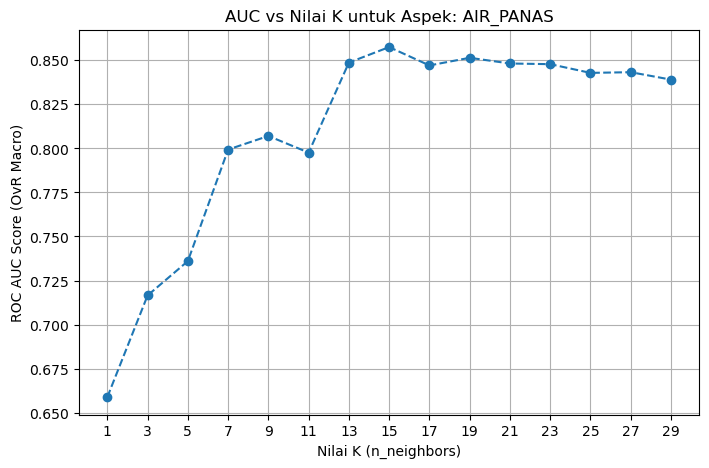

Melatih model KNN final untuk 'air_panas' dengan k=15...
Laporan Klasifikasi untuk 'air_panas':
              precision    recall  f1-score   support

           0       0.69      0.53      0.60        38
           1       0.93      0.98      0.95       245
           2       0.00      0.00      0.00         3

    accuracy                           0.91       286
   macro avg       0.54      0.50      0.52       286
weighted avg       0.89      0.91      0.90       286


----- Memproses Aspek: BAU -----
Mencari k optimal untuk 'bau' dari rentang [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]...
==> Nilai k optimal untuk 'bau' adalah 15 dengan AUC (OvR Macro) = 0.6544


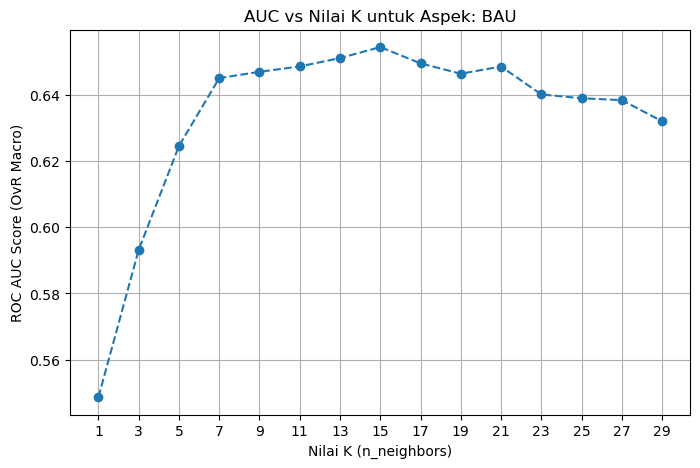

Melatih model KNN final untuk 'bau' dengan k=15...
Laporan Klasifikasi untuk 'bau':
              precision    recall  f1-score   support

           0       0.52      0.32      0.39        41
           1       0.89      0.95      0.92       244
           2       0.00      0.00      0.00         1

    accuracy                           0.86       286
   macro avg       0.47      0.42      0.44       286
weighted avg       0.83      0.86      0.84       286


----- Memproses Aspek: GENERAL -----
Mencari k optimal untuk 'general' dari rentang [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]...
==> Nilai k optimal untuk 'general' adalah 21 dengan AUC (OvR Macro) = 0.6383


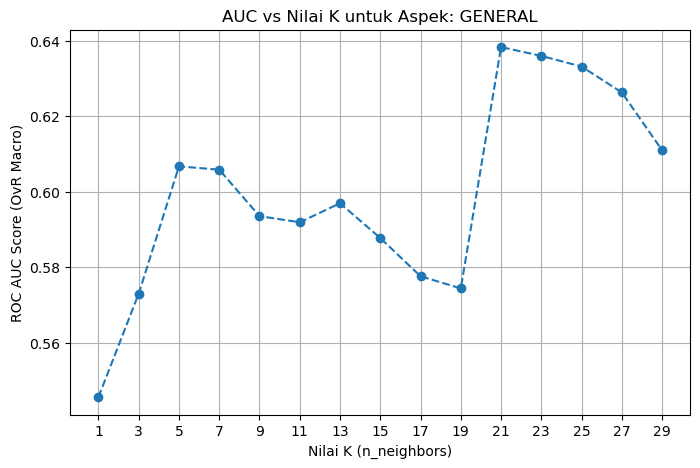

Melatih model KNN final untuk 'general' dengan k=21...
Laporan Klasifikasi untuk 'general':
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.85      1.00      0.92       243
           2       0.00      0.00      0.00        38

    accuracy                           0.85       286
   macro avg       0.28      0.33      0.31       286
weighted avg       0.72      0.85      0.78       286


----- Memproses Aspek: KEBERSIHAN -----
Peringatan: Data untuk aspek 'kebersihan' tidak valid untuk optimasi AUC.
   Kelas di data latih: [0 1 2 3]
   Kelas di data uji  : [0 1 2]
   Optimasi dilewati, menggunakan k=5 sebagai default.
Melatih model KNN final untuk 'kebersihan' dengan k=5...
Laporan Klasifikasi untuk 'kebersihan':
              precision    recall  f1-score   support

           0       0.56      0.71      0.62        96
           1       0.75      0.73      0.74       158
           2       0.20      0.

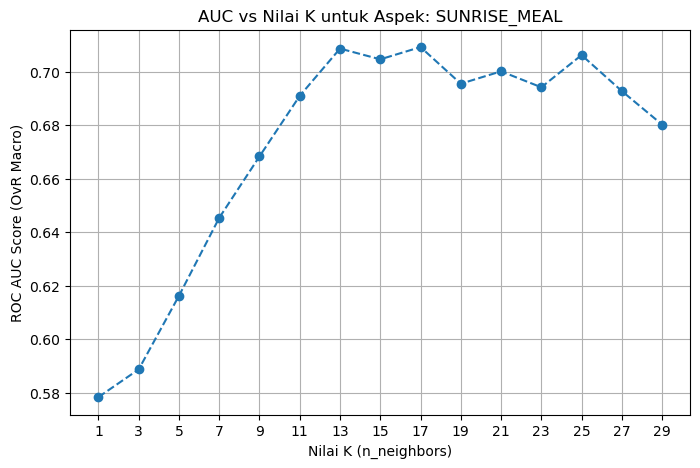

Melatih model KNN final untuk 'sunrise_meal' dengan k=17...
Laporan Klasifikasi untuk 'sunrise_meal':
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.92      1.00      0.96       264
           2       0.00      0.00      0.00         8

    accuracy                           0.92       286
   macro avg       0.31      0.33      0.32       286
weighted avg       0.85      0.92      0.89       286


----- Memproses Aspek: TV -----
Mencari k optimal untuk 'tv' dari rentang [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]...
==> Nilai k optimal untuk 'tv' adalah 21 dengan AUC (OvR Macro) = 0.7970


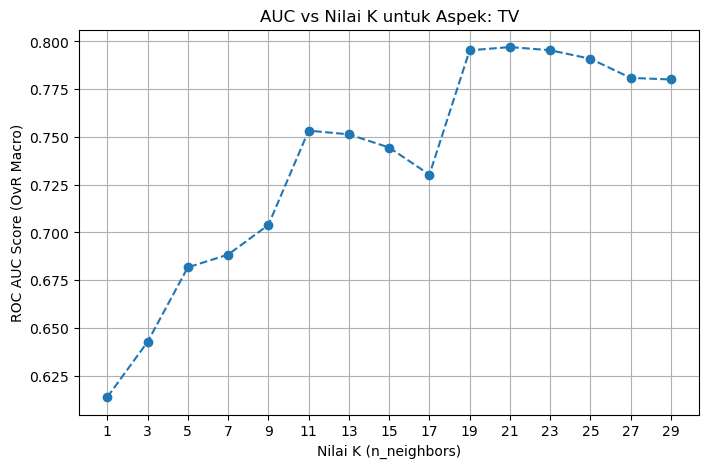

Melatih model KNN final untuk 'tv' dengan k=21...
Laporan Klasifikasi untuk 'tv':
              precision    recall  f1-score   support

           0       1.00      0.04      0.07        26
           1       0.90      1.00      0.95       257
           2       0.00      0.00      0.00         3

    accuracy                           0.90       286
   macro avg       0.63      0.35      0.34       286
weighted avg       0.90      0.90      0.86       286


----- Memproses Aspek: WIFI -----
Mencari k optimal untuk 'wifi' dari rentang [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]...
==> Nilai k optimal untuk 'wifi' adalah 21 dengan AUC (OvR Macro) = 0.7954


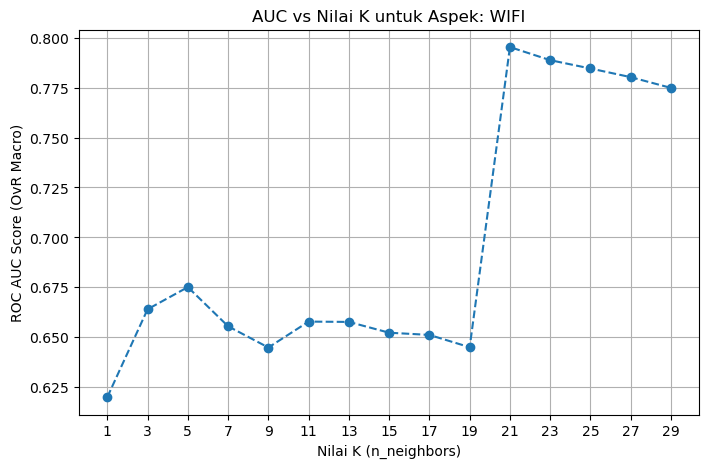

Melatih model KNN final untuk 'wifi' dengan k=21...
Laporan Klasifikasi untuk 'wifi':
              precision    recall  f1-score   support

           0       0.70      0.20      0.31        35
           1       0.89      0.99      0.94       250
           2       0.00      0.00      0.00         1

    accuracy                           0.89       286
   macro avg       0.53      0.40      0.42       286
weighted avg       0.87      0.89      0.86       286


--- Hasil Evaluasi Gabungan KNN (Micro Average) ---
Precision (Micro Average): 0.8388
Recall (Micro Average): 0.8388
F1-Score (Micro Average): 0.8388


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, roc_auc_score

# Asumsikan variabel-variabel ini sudah ada dari proses sebelumnya
# train_df, test_df, X_train_bow, X_test_bow

print("Mempersiapkan data untuk pemodelan K-Nearest Neighbour (KNN)...")

# 1. Tentukan kolom target
aspek_sentimen = [
    "ac", "air_panas", "bau", "general", "kebersihan",
    "linen", "service", "sunrise_meal", "tv", "wifi"
]

# 2. Siapkan data target
y_train = train_df[aspek_sentimen].fillna(1).astype(int).values
y_test = test_df[aspek_sentimen].fillna(1).astype(int).values

# 3. Siapkan list prediksi
all_predictions_knn = []

print("\n--- Mencari K Optimal dan Melatih Model KNN untuk Setiap Aspek (Mode Multi-Kelas) ---")

# 4. Loop untuk setiap aspek
for i, aspek in enumerate(aspek_sentimen):
    print(f"\n----- Memproses Aspek: {aspek.upper()} -----")

    y_train_aspek = y_train[:, i]
    y_test_aspek = y_test[:, i]

    # --- PERBAIKAN FINAL: Satu pengecekan komprehensif untuk validitas data ---
    train_classes = np.unique(y_train_aspek)
    test_classes = np.unique(y_test_aspek)

    # Kondisi tidak valid jika:
    # 1. Data latih punya kurang dari 2 kelas.
    # 2. Set kelas di data latih tidak sama persis dengan di data uji.
    if len(train_classes) < 2 or set(train_classes) != set(test_classes):
        print(f"Peringatan: Data untuk aspek '{aspek}' tidak valid untuk optimasi AUC.")
        print(f"   Kelas di data latih: {train_classes}")
        print(f"   Kelas di data uji  : {test_classes}")
        print("   Optimasi dilewati, menggunakan k=5 sebagai default.")
        best_k = 5
    else:
        # Blok optimisasi hanya berjalan jika data valid dan konsisten
        k_values = range(1, 31, 2)
        auc_scores = []
        print(f"Mencari k optimal untuk '{aspek}' dari rentang {list(k_values)}...")

        for k in k_values:
            knn_temp = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
            knn_temp.fit(X_train_w2v, y_train_aspek)

            y_pred_proba = knn_temp.predict_proba(X_test_w2v)

            # Karena set kelas sudah dipastikan sama, roc_auc_score akan berjalan lancar
            auc = roc_auc_score(y_test_aspek, y_pred_proba, multi_class='ovr', average='macro')
            auc_scores.append(auc)

        best_auc = max(auc_scores)
        best_k = k_values[np.argmax(auc_scores)]
        print(f"==> Nilai k optimal untuk '{aspek}' adalah {best_k} dengan AUC (OvR Macro) = {best_auc:.4f}")

        plt.figure(figsize=(8, 5))
        plt.plot(k_values, auc_scores, marker='o', linestyle='--')
        plt.title(f'AUC vs Nilai K untuk Aspek: {aspek.upper()}')
        plt.xlabel('Nilai K (n_neighbors)')
        plt.ylabel('ROC AUC Score (OvR Macro)')
        plt.xticks(k_values)
        plt.grid(True)
        plt.show()

    # Latih model final dengan k terbaik (hasil optimasi atau default)
    print(f"Melatih model KNN final untuk '{aspek}' dengan k={best_k}...")
    knn_model = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
    knn_model.fit(X_train_w2v, y_train_aspek)
    y_pred_aspek_knn = knn_model.predict(X_test_w2v)
    all_predictions_knn.append(y_pred_aspek_knn)

    print(f"Laporan Klasifikasi untuk '{aspek}':")
    print(classification_report(y_test_aspek, y_pred_aspek_knn, zero_division=0, labels=np.unique(y_test_aspek)))


# Evaluasi gabungan
y_pred_knn = np.array(all_predictions_knn).T
if y_pred_knn.size > 0:
    print("\n--- Hasil Evaluasi Gabungan KNN (Micro Average) ---")
    y_test_flat = y_test.flatten()
    y_pred_knn_flat = y_pred_knn.flatten()
    precision_knn = precision_score(y_test_flat, y_pred_knn_flat, average='micro')
    recall_knn = recall_score(y_test_flat, y_pred_knn_flat, average='micro')
    f1_knn = f1_score(y_test_flat, y_pred_knn_flat, average='micro')
    print(f"Precision (Micro Average): {precision_knn:.4f}")
    print(f"Recall (Micro Average): {recall_knn:.4f}")
    print(f"F1-Score (Micro Average): {f1_knn:.4f}")
else:
    print("\nTidak ada model yang berhasil dilatih, evaluasi gabungan dilewati.")

#### K-NN dengan teknik imbalance data
oversampling menggunakan RandomOverSampler

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
# Anda perlu menginstal library imbalanced-learn terlebih dahulu.
# Jalankan baris ini di cell terpisah jika belum terinstal:
# !pip install imbalanced-learn
from imblearn.over_sampling import RandomOverSampler

# --- TAHAP 11: IMPLEMENTASI K-NEAREST NEIGHBOUR (KNN) DENGAN OVERSAMPLING ---
# Tahap ini dijalankan setelah cell 'Bag of Words' dieksekusi.
# Kita asumsikan variabel-variabel berikut sudah ada:
# train_df, test_df, X_train_bow, X_test_bow

print("Mempersiapkan data untuk pemodelan K-Nearest Neighbour (KNN)...")

# 1. Tentukan kolom target (aspek sentimen)
aspek_sentimen = [
    "ac", "air_panas", "bau", "general", "kebersihan", 
    "linen", "service", "sunrise_meal", "tv", "wifi"
]

# 2. Siapkan data target (y) untuk training dan testing
y_train = train_df[aspek_sentimen].fillna(1).astype(int).values
y_test = test_df[aspek_sentimen].fillna(1).astype(int).values

# 3. Siapkan list untuk menyimpan hasil prediksi dari setiap model
all_predictions_knn = []

print("\n--- Melatih dan Mengevaluasi Model KNN untuk Setiap Aspek ---")

# 4. Loop untuk setiap aspek sentimen
for i, aspek in enumerate(aspek_sentimen):
    print(f"\n----- Memproses Aspek: {aspek.upper()} -----")

    # Ambil data target untuk aspek saat ini
    y_train_aspek = y_train[:, i]
    y_test_aspek = y_test[:, i]

    # --- MENGATASI IMBALANCED DATA DENGAN OVERSAMPLING ---
    print(f"Menerapkan RandomOverSampler untuk aspek '{aspek}'...")
    ros = RandomOverSampler(random_state=42)
    X_train_resampled, y_train_resampled = ros.fit_resample(X_train_w2v, y_train_aspek)

    # Inisialisasi model KNN untuk aspek ini
    # Menggunakan n_neighbors=5 sebagai nilai awal yang umum.
    knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    
    # Latih model menggunakan data yang sudah di-resample
    print(f"Melatih model KNN untuk aspek '{aspek}'...")
    knn_model.fit(X_train_resampled, y_train_resampled)
    
    # Buat prediksi
    y_pred_aspek_knn = knn_model.predict(X_test_w2v)
    
    # Simpan hasil prediksi
    all_predictions_knn.append(y_pred_aspek_knn)
    
    # Tampilkan laporan klasifikasi untuk aspek ini
    print(f"Laporan Klasifikasi untuk '{aspek}':")
    print(classification_report(y_test_aspek, y_pred_aspek_knn, zero_division=0))

# 5. Gabungkan semua prediksi menjadi satu matriks
y_pred_knn = np.array(all_predictions_knn).T

# 6. Hitung dan tampilkan metrik evaluasi gabungan
print("\n--- Hasil Evaluasi Gabungan KNN (Micro Average) ---")

# Ratakan (flatten) array y_test dan y_pred sebelum menghitung metrik gabungan.
y_test_flat = y_test.flatten()
y_pred_knn_flat = y_pred_knn.flatten()

precision_knn = precision_score(y_test_flat, y_pred_knn_flat, average='micro')
recall_knn = recall_score(y_test_flat, y_pred_knn_flat, average='micro')
f1_knn = f1_score(y_test_flat, y_pred_knn_flat, average='micro')

print(f"Precision (Micro Average): {precision_knn:.4f}")
print(f"Recall (Micro Average): {recall_knn:.4f}")
print(f"F1-Score (Micro Average): {f1_knn:.4f}")


Mempersiapkan data untuk pemodelan K-Nearest Neighbour (KNN)...

--- Melatih dan Mengevaluasi Model KNN untuk Setiap Aspek ---

----- Memproses Aspek: AC -----
Menerapkan RandomOverSampler untuk aspek 'ac'...
Melatih model KNN untuk aspek 'ac'...
Laporan Klasifikasi untuk 'ac':
              precision    recall  f1-score   support

           0       0.37      0.64      0.47        45
           1       0.94      0.74      0.83       233
           2       0.09      0.25      0.13         8

    accuracy                           0.71       286
   macro avg       0.46      0.55      0.48       286
weighted avg       0.83      0.71      0.75       286


----- Memproses Aspek: AIR_PANAS -----
Menerapkan RandomOverSampler untuk aspek 'air_panas'...
Melatih model KNN untuk aspek 'air_panas'...
Laporan Klasifikasi untuk 'air_panas':
              precision    recall  f1-score   support

           0       0.42      0.74      0.53        38
           1       0.95      0.82      0.88       2

#### K-NN dengan teknik imbalanced data dan ROC

Mempersiapkan data untuk pemodelan K-Nearest Neighbour (KNN)...

--- Mencari K Optimal dan Melatih Model KNN untuk Setiap Aspek (Mode Multi-Kelas) ---

----- Memproses Aspek: AC -----
Distribusi kelas 'ac' sebelum oversampling: Counter({1: 1814, 0: 417, 2: 51, 3: 1})
Distribusi kelas 'ac' setelah oversampling:  Counter({1: 1814, 0: 1814, 2: 1814, 3: 1814})
Peringatan: Data untuk aspek 'ac' tidak valid untuk optimasi AUC.
   Kelas di data latih (setelah resample): [0 1 2 3]
   Kelas di data uji  : [0 1 2]
   Optimasi dilewati, menggunakan k=5 sebagai default.
Melatih model KNN final untuk 'ac' dengan k=5...
Laporan Klasifikasi untuk 'ac':
              precision    recall  f1-score   support

           0       0.42      0.71      0.52        45
           1       0.95      0.78      0.86       233
           2       0.11      0.25      0.15         8

    accuracy                           0.75       286
   macro avg       0.49      0.58      0.51       286
weighted avg       0.84     

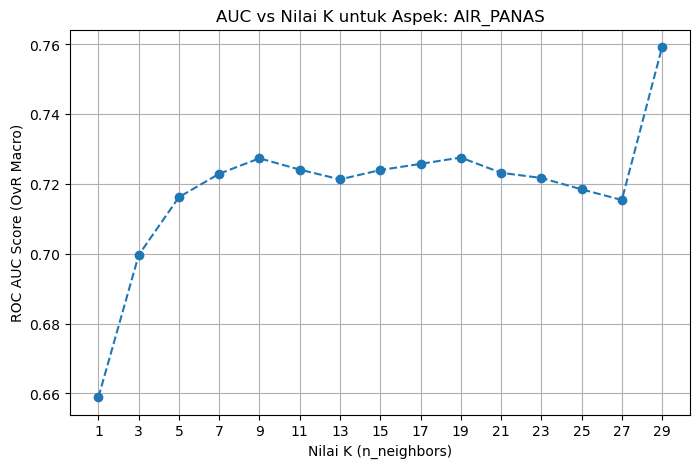

Melatih model KNN final untuk 'air_panas' dengan k=29...
Laporan Klasifikasi untuk 'air_panas':
              precision    recall  f1-score   support

           0       0.44      0.76      0.56        38
           1       0.97      0.74      0.84       245
           2       0.00      0.00      0.00         3

    accuracy                           0.73       286
   macro avg       0.47      0.50      0.47       286
weighted avg       0.89      0.73      0.79       286


----- Memproses Aspek: BAU -----
Distribusi kelas 'bau' sebelum oversampling: Counter({1: 1911, 0: 360, 2: 12})
Distribusi kelas 'bau' setelah oversampling:  Counter({1: 1911, 0: 1911, 2: 1911})
Mencari k optimal untuk 'bau' dari rentang [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]...
==> Nilai k optimal untuk 'bau' adalah 29 dengan AUC (OvR Macro) = 0.6206


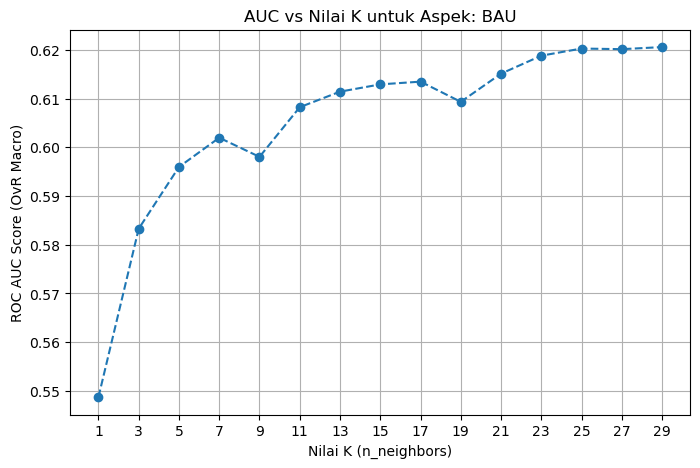

Melatih model KNN final untuk 'bau' dengan k=29...
Laporan Klasifikasi untuk 'bau':
              precision    recall  f1-score   support

           0       0.24      0.73      0.36        41
           1       0.94      0.52      0.67       244
           2       0.00      0.00      0.00         1

    accuracy                           0.55       286
   macro avg       0.39      0.42      0.35       286
weighted avg       0.84      0.55      0.63       286


----- Memproses Aspek: GENERAL -----
Distribusi kelas 'general' sebelum oversampling: Counter({1: 2023, 2: 230, 0: 30})
Distribusi kelas 'general' setelah oversampling:  Counter({1: 2023, 2: 2023, 0: 2023})
Mencari k optimal untuk 'general' dari rentang [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]...
==> Nilai k optimal untuk 'general' adalah 29 dengan AUC (OvR Macro) = 0.6255


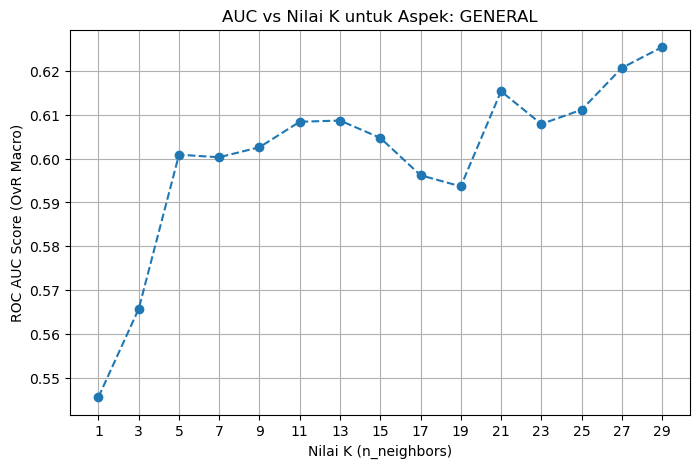

Melatih model KNN final untuk 'general' dengan k=29...
Laporan Klasifikasi untuk 'general':
              precision    recall  f1-score   support

           0       0.02      0.20      0.04         5
           1       0.91      0.43      0.58       243
           2       0.21      0.71      0.32        38

    accuracy                           0.47       286
   macro avg       0.38      0.45      0.32       286
weighted avg       0.80      0.47      0.54       286


----- Memproses Aspek: KEBERSIHAN -----
Distribusi kelas 'kebersihan' sebelum oversampling: Counter({1: 1350, 0: 722, 2: 205, 3: 6})
Distribusi kelas 'kebersihan' setelah oversampling:  Counter({0: 1350, 2: 1350, 1: 1350, 3: 1350})
Peringatan: Data untuk aspek 'kebersihan' tidak valid untuk optimasi AUC.
   Kelas di data latih (setelah resample): [0 1 2 3]
   Kelas di data uji  : [0 1 2]
   Optimasi dilewati, menggunakan k=5 sebagai default.
Melatih model KNN final untuk 'kebersihan' dengan k=5...
Laporan Klasifikasi unt

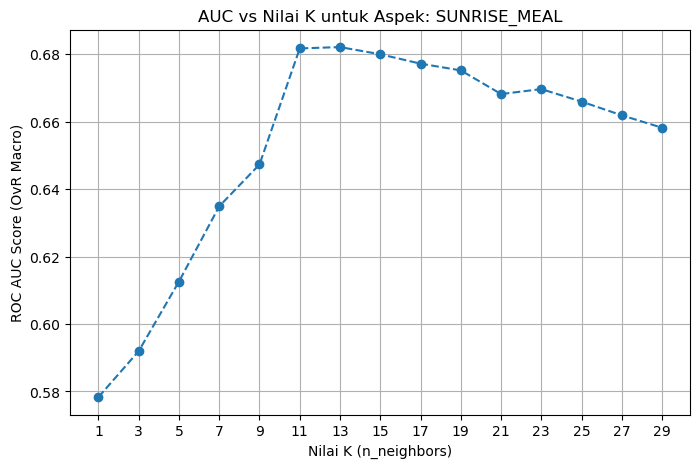

Melatih model KNN final untuk 'sunrise_meal' dengan k=13...
Laporan Klasifikasi untuk 'sunrise_meal':
              precision    recall  f1-score   support

           0       0.09      0.50      0.15        14
           1       0.97      0.56      0.71       264
           2       0.06      0.38      0.10         8

    accuracy                           0.55       286
   macro avg       0.37      0.48      0.32       286
weighted avg       0.90      0.55      0.66       286


----- Memproses Aspek: TV -----
Distribusi kelas 'tv' sebelum oversampling: Counter({1: 2075, 0: 195, 2: 13})
Distribusi kelas 'tv' setelah oversampling:  Counter({1: 2075, 0: 2075, 2: 2075})
Mencari k optimal untuk 'tv' dari rentang [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]...
==> Nilai k optimal untuk 'tv' adalah 27 dengan AUC (OvR Macro) = 0.7185


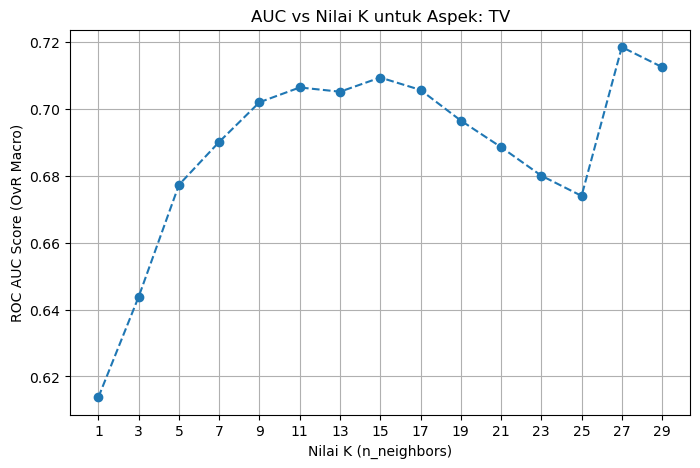

Melatih model KNN final untuk 'tv' dengan k=27...
Laporan Klasifikasi untuk 'tv':
              precision    recall  f1-score   support

           0       0.20      0.69      0.31        26
           1       0.96      0.67      0.79       257
           2       0.00      0.00      0.00         3

    accuracy                           0.66       286
   macro avg       0.39      0.45      0.36       286
weighted avg       0.88      0.66      0.73       286


----- Memproses Aspek: WIFI -----
Distribusi kelas 'wifi' sebelum oversampling: Counter({1: 1928, 0: 330, 2: 25})
Distribusi kelas 'wifi' setelah oversampling:  Counter({1: 1928, 0: 1928, 2: 1928})
Mencari k optimal untuk 'wifi' dari rentang [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]...
==> Nilai k optimal untuk 'wifi' adalah 11 dengan AUC (OvR Macro) = 0.6587


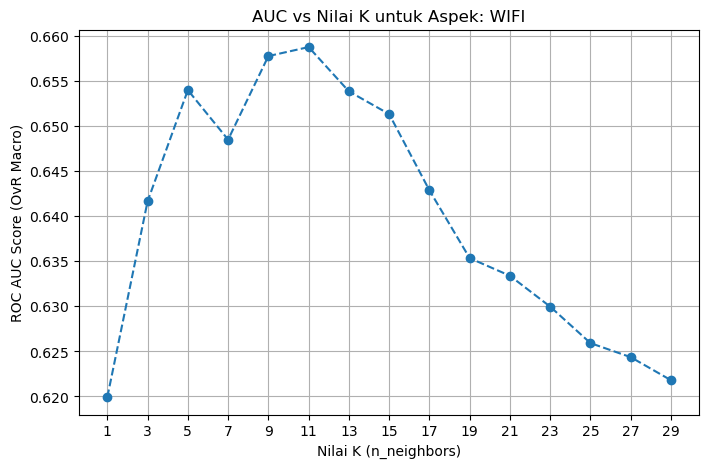

Melatih model KNN final untuk 'wifi' dengan k=11...
Laporan Klasifikasi untuk 'wifi':
              precision    recall  f1-score   support

           0       0.24      0.69      0.36        35
           1       0.94      0.66      0.77       250
           2       0.00      0.00      0.00         1

    accuracy                           0.66       286
   macro avg       0.39      0.45      0.38       286
weighted avg       0.85      0.66      0.72       286


--- Hasil Evaluasi Gabungan KNN (Micro Average) ---
Precision (Micro Average): 0.6171
Recall (Micro Average): 0.6171
F1-Score (Micro Average): 0.6171


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, roc_auc_score
# --- IMPORT BARU ---
from imblearn.over_sampling import RandomOverSampler

# Pastikan library imbalanced-learn sudah terinstal
# pip install -U imbalanced-learn

# Asumsikan variabel-variabel ini sudah ada dari proses sebelumnya
# train_df, test_df, X_train_bow, X_test_bow

print("Mempersiapkan data untuk pemodelan K-Nearest Neighbour (KNN)...")

# 1. Tentukan kolom target
aspek_sentimen = [
    "ac", "air_panas", "bau", "general", "kebersihan",
    "linen", "service", "sunrise_meal", "tv", "wifi"
]

# 2. Siapkan data target
y_train = train_df[aspek_sentimen].fillna(1).astype(int).values
y_test = test_df[aspek_sentimen].fillna(1).astype(int).values

# 3. Siapkan list prediksi
all_predictions_knn = []

print("\n--- Mencari K Optimal dan Melatih Model KNN untuk Setiap Aspek (Mode Multi-Kelas) ---")

# 4. Loop untuk setiap aspek
for i, aspek in enumerate(aspek_sentimen):
    print(f"\n----- Memproses Aspek: {aspek.upper()} -----")

    y_train_aspek = y_train[:, i]
    y_test_aspek = y_test[:, i]

    # --- PENAMBAHAN RandomOverSampler DIMULAI DI SINI ---
    # Terapkan oversampling HANYA pada data latih
    ros = RandomOverSampler(random_state=42)
    print(f"Distribusi kelas '{aspek}' sebelum oversampling: {Counter(y_train_aspek)}")
    X_train_resampled, y_train_resampled = ros.fit_resample(X_train_w2v, y_train_aspek)
    print(f"Distribusi kelas '{aspek}' setelah oversampling:  {Counter(y_train_resampled)}")
    # --- PENAMBAHAN SELESAI ---

    # Gunakan data yang sudah di-resample untuk pengecekan dan pelatihan
    train_classes = np.unique(y_train_resampled)
    test_classes = np.unique(y_test_aspek)

    if len(train_classes) < 2 or set(train_classes) != set(test_classes):
        print(f"Peringatan: Data untuk aspek '{aspek}' tidak valid untuk optimasi AUC.")
        print(f"   Kelas di data latih (setelah resample): {train_classes}")
        print(f"   Kelas di data uji  : {test_classes}")
        print("   Optimasi dilewati, menggunakan k=5 sebagai default.")
        best_k = 5
    else:
        k_values = range(1, 31, 2)
        auc_scores = []
        print(f"Mencari k optimal untuk '{aspek}' dari rentang {list(k_values)}...")

        for k in k_values:
            knn_temp = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
            # Latih model sementara dengan data resampled
            knn_temp.fit(X_train_resampled, y_train_resampled)

            # Evaluasi tetap pada data uji yang asli
            y_pred_proba = knn_temp.predict_proba(X_test_w2v)
            auc = roc_auc_score(y_test_aspek, y_pred_proba, multi_class='ovr', average='macro')
            auc_scores.append(auc)

        best_auc = max(auc_scores)
        best_k = k_values[np.argmax(auc_scores)]
        print(f"==> Nilai k optimal untuk '{aspek}' adalah {best_k} dengan AUC (OvR Macro) = {best_auc:.4f}")

        plt.figure(figsize=(8, 5))
        plt.plot(k_values, auc_scores, marker='o', linestyle='--')
        plt.title(f'AUC vs Nilai K untuk Aspek: {aspek.upper()}')
        plt.xlabel('Nilai K (n_neighbors)')
        plt.ylabel('ROC AUC Score (OvR Macro)')
        plt.xticks(k_values)
        plt.grid(True)
        plt.show()

    # Latih model final dengan k terbaik menggunakan data resampled
    print(f"Melatih model KNN final untuk '{aspek}' dengan k={best_k}...")
    knn_model = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
    knn_model.fit(X_train_resampled, y_train_resampled)
    
    # Prediksi tetap dilakukan pada data uji yang asli
    y_pred_aspek_knn = knn_model.predict(X_test_w2v)
    all_predictions_knn.append(y_pred_aspek_knn)

    print(f"Laporan Klasifikasi untuk '{aspek}':")
    print(classification_report(y_test_aspek, y_pred_aspek_knn, zero_division=0, labels=np.unique(y_test_aspek)))


# Evaluasi gabungan (tidak ada perubahan di sini)
y_pred_knn = np.array(all_predictions_knn).T
if y_pred_knn.size > 0:
    print("\n--- Hasil Evaluasi Gabungan KNN (Micro Average) ---")
    y_test_flat = y_test.flatten()
    y_pred_knn_flat = y_pred_knn.flatten()
    precision_knn = precision_score(y_test_flat, y_pred_knn_flat, average='micro')
    recall_knn = recall_score(y_test_flat, y_pred_knn_flat, average='micro')
    f1_knn = f1_score(y_test_flat, y_pred_knn_flat, average='micro')
    print(f"Precision (Micro Average): {precision_knn:.4f}")
    print(f"Recall (Micro Average): {recall_knn:.4f}")
    print(f"F1-Score (Micro Average): {f1_knn:.4f}")
else:
    print("\nTidak ada model yang berhasil dilatih, evaluasi gabungan dilewati.")

#### Hybrid Classifier

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

# --- TAHAP 12: IMPLEMENTASI HYBRID CLASSIFIER (STACKING LANJUTAN) ---
print("Mempersiapkan data untuk Stacking Classifier...")

aspek_sentimen = [
    "ac", "air_panas", "bau", "general", "kebersihan", 
    "linen", "service", "sunrise_meal", "tv", "wifi"
]
y_train = train_df[aspek_sentimen].fillna(1).astype(int).values
y_test = test_df[aspek_sentimen].fillna(1).astype(int).values

final_predictions = []

print("\n--- Melatih Stacking Classifier untuk Setiap Aspek ---")

for i, aspek in enumerate(aspek_sentimen):
    print(f"\n----- Memproses Aspek: {aspek.upper()} -----")

    y_train_aspek = y_train[:, i]
    y_test_aspek = y_test[:, i]

    X_train_stack, X_val_stack, y_train_stack, y_val_stack = train_test_split(
        X_train_w2v, y_train_aspek, test_size=0.2, random_state=42
    )

    # Base models tanpa MultinomialNB
    base_models = [
        ('RandomForest', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)),
        ('SVM', SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42)),
        ('KNN', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
    ]

    val_meta_features = []
    test_meta_features = []

    for name, model in base_models:
        print(f"Melatih {name}...")

        if name == 'KNN':
            ros = RandomOverSampler(random_state=42)
            X_train_resampled, y_train_resampled = ros.fit_resample(X_train_stack, y_train_stack)
            model.fit(X_train_resampled, y_train_resampled)
        else:
            model.fit(X_train_stack, y_train_stack)

        val_preds = model.predict_proba(X_val_stack)
        val_meta_features.append(val_preds)

        test_preds = model.predict_proba(X_test_w2v)
        test_meta_features.append(test_preds)

    X_meta_train = np.hstack(val_meta_features)
    X_meta_test = np.hstack(test_meta_features)

    print("Melatih Meta-Model (Logistic Regression)...")
    meta_model = LogisticRegression(max_iter=1000, random_state=42)
    meta_model.fit(X_meta_train, y_val_stack)

    y_pred_aspek = meta_model.predict(X_meta_test)
    final_predictions.append(y_pred_aspek)

y_pred_stacking = np.array(final_predictions).T

print("\n--- Hasil Evaluasi Hybrid Classifier (Stacking) ---")
y_test_flat = y_test.flatten()
y_pred_stacking_flat = y_pred_stacking.flatten()

precision_stacking = precision_score(y_test_flat, y_pred_stacking_flat, average='micro')
recall_stacking = recall_score(y_test_flat, y_pred_stacking_flat, average='micro')
f1_stacking = f1_score(y_test_flat, y_pred_stacking_flat, average='micro')

print(f"Precision (Micro Average): {precision_stacking:.4f}")
print(f"Recall (Micro Average): {recall_stacking:.4f}")
print(f"F1-Score (Micro Average): {f1_stacking:.4f}")

print("\n--- Laporan Klasifikasi per Aspek (Stacking) ---")
for i, aspek in enumerate(aspek_sentimen):
    print(f"\nLaporan untuk Aspek: {aspek.upper()}")
    print(classification_report(y_test[:, i], y_pred_stacking[:, i], zero_division=0))

Mempersiapkan data untuk Stacking Classifier...

--- Melatih Stacking Classifier untuk Setiap Aspek ---

----- Memproses Aspek: AC -----
Melatih RandomForest...
Melatih SVM...
Melatih KNN...
Melatih Meta-Model (Logistic Regression)...

----- Memproses Aspek: AIR_PANAS -----
Melatih RandomForest...
Melatih SVM...
Melatih KNN...
Melatih Meta-Model (Logistic Regression)...

----- Memproses Aspek: BAU -----
Melatih RandomForest...
Melatih SVM...
Melatih KNN...
Melatih Meta-Model (Logistic Regression)...

----- Memproses Aspek: GENERAL -----
Melatih RandomForest...
Melatih SVM...
Melatih KNN...
Melatih Meta-Model (Logistic Regression)...

----- Memproses Aspek: KEBERSIHAN -----
Melatih RandomForest...
Melatih SVM...
Melatih KNN...
Melatih Meta-Model (Logistic Regression)...

----- Memproses Aspek: LINEN -----
Melatih RandomForest...
Melatih SVM...
Melatih KNN...
Melatih Meta-Model (Logistic Regression)...

----- Memproses Aspek: SERVICE -----
Melatih RandomForest...
Melatih SVM...
Melatih K

### Evaluation Matrix